### В данном файле:
1) вычитываем биткойн-датасет и сохраняем в original.csv
2) получаем для этого датасета отчет. Наша цель понять, есть ли в датасете n/a, дубликаты, категориальные признаки
3) ориентируясь на результатах base_report, заполняем n/a через функцию интерполяции, а дату за мегняем на {year, month, day, day_of_week} с целью отловить потенциальные сезонные всплески
4) Визуализируем:
    * важность признаков
    * диаграмму корреляции
5) На базе первичной (п.4) визуализации сокращаем некоторые признаки
6) Для итогового набора признаков строим графики:
    * гистограмма частот
    * линейным графиком временного ряда с линией среднего
    * 'ящик с усами'
6) Сохраняем сокращенный датасет в reduced.csv

In [ ]:
%pip install colorama pandas matplotlib kagglehub jinja2 scikit-learn seaborn lightgbm xgboost catboost optuna

In [ ]:
%pip install --upgrade nbformat ipykernel

In [ ]:
%pip install --upgrade jupyter ipywidgets

In [ ]:
# import kagglehub

# path = kagglehub.dataset_download("purnamaridzkynugraha/bitcoin-historical-data")

# print("Path to dataset files:", path)

#### Columns description:
* date : Дата начала торгов
* adj close : Ежедневные данные о цене OHLCV для BTC-USD
* close : Ежедневные данные о цене OHL_C_V для BTC-USD 
* high : Ежедневные данные о цене O_H_LCV для BTC-USD 
* low : Ежедневные данные о цене OH_L_CV для BTC-USD
* open : Ежедневные данные о цене _O_HLCV для BTC-USD
* volume : Величина ежедневного объема торгов
* sp500_close : Цена закрытия индекса S&P 500 (показатель состояния фондового рынка США)
* gold_close : Цена фьючерсов на золото (индикатор активов-убежищ)
* dxy_close : Индекс доллара США (показатель силы фиатной валюты)
* fng_score : Индекс страха и жадности перед криптовалютами (0-100) : 
    * 0-25 (Крайний страх): Признак рыночной паники (потенциальная возможность для покупки)
    * 75-100 (Крайняя жадность): Признак рыночного оптимизма (потенциальная коррекция)
* google_trends_score : Относительный объем поисковых запросов по ключевому слову "Биткойн" (показатель ажиотажа/интереса со стороны розничных инвесторов)
* btc_return : Ежедневная простая процентная доходность
* btc_log_return : Ежедневная логарифмическая доходность (предпочтительно для моделей машинного обучения)
* sp500_return : Ежедневная доходность макроактивов (фондовый рынок США)
* gold_return : Ежедневная доходность макроактивов (индикатор активов-убежищ) 
* dxy_return : Ежедневная доходность макроактивов (показатель силы фиатной валюты)
* btc_vol_7d : Скользящая волатильность (стандартное отклонение) за 7 дней
* btc_vol_14d : Скользящая волатильность (стандартное отклонение) за 14 дней
-----------------------------------------------------------------------------
* target_return: Рост цены биткоина за следующие 14 дней.
* target_direction: Бинарная классификационная метка ( 1 = Вверх, 0 = Вниз/Плоско) на следующие 14 дней

In [1]:
import pandas as pd

from private.utils import (
    base_report,
    correlogram,
    feature_importance,
    feature_plot,
    load_bitcoin_data,
)

df_original = load_bitcoin_data()

base_report(df_original, '')

rows × cols,n/a,duplicates,0-columns,types
1826×22,46,0,0,"float64(19), int64(2), str(1)"


not numeric: ['date']
n/a:


google_trends_score,btc_return,btc_log_return,sp500_return,gold_return,dxy_return,btc_vol_7d,btc_vol_14d,target_return
6,1,1,1,1,1,7,14,14


#### Задача : заполнить n/a : 

In [2]:
for name in df_original.columns[df_original.isna().any()].tolist():
    df_original[name] = df_original[name].interpolate(limit_direction='both')

base_report(df_original, '')

rows × cols,n/a,duplicates,0-columns,types
1826×22,0,0,0,"float64(19), int64(2), str(1)"


not numeric: ['date']


#### Преобразуем:
1) дату ->  год + месяц + день + день недели
2) оставим в качестве target пока только target_return

In [3]:
df_original = df_original.drop(columns=["target_direction"])

df_original["date"] = pd.to_datetime(df_original["date"])

df_original["year"] = df_original["date"].dt.year
df_original["month"] = df_original["date"].dt.month
df_original["day"] = df_original["date"].dt.day
df_original["day_of_week"] = df_original["date"].dt.dayofweek

df_original = df_original.drop(columns=["date"])

base_report(df_original, 'target_return')

rows × cols,n/a,duplicates,0-columns,types
1826×24,0,0,0,"float64(19), int32(4), int64(1)"


#### Визуализация :
1) оценить feature_importamce
2) матрица взаимной корреляции
3) гистограммы, графики, 'ящики с усами'  

#### Визуализация: feature_importance

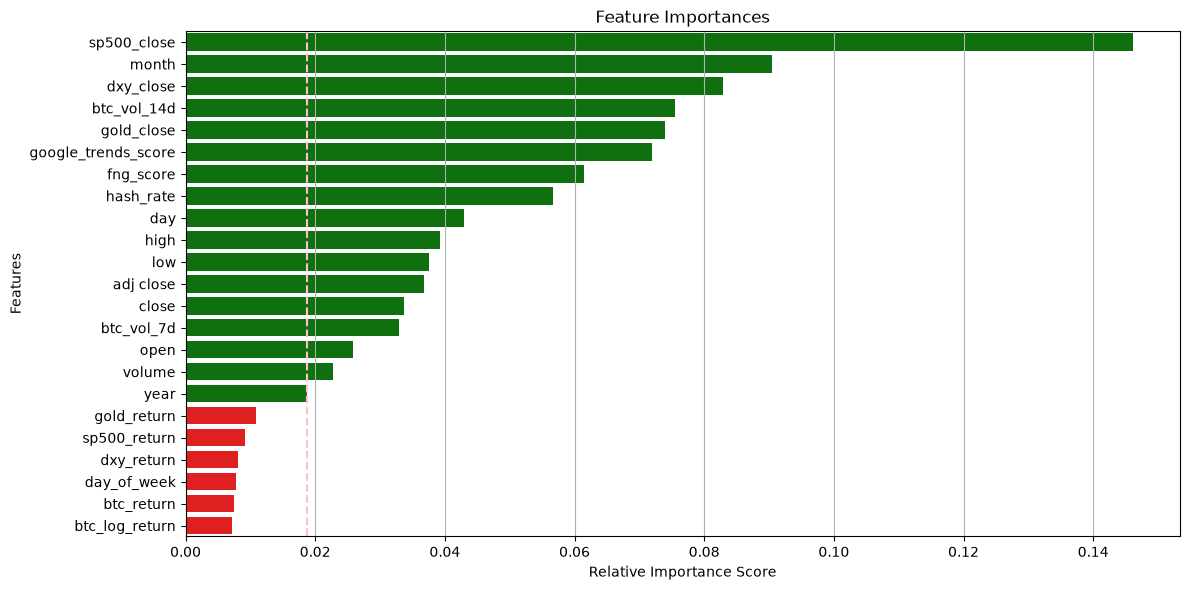

In [4]:
feature_importance(
    X=df_original.drop(columns=['target_return']),
    y=df_original['target_return']
)

#### Вывод:
* нет признаков с нулевой значимостью, поэтому не будем исключать "красные" признаки из датасета

#### Диалграмма корреляции:

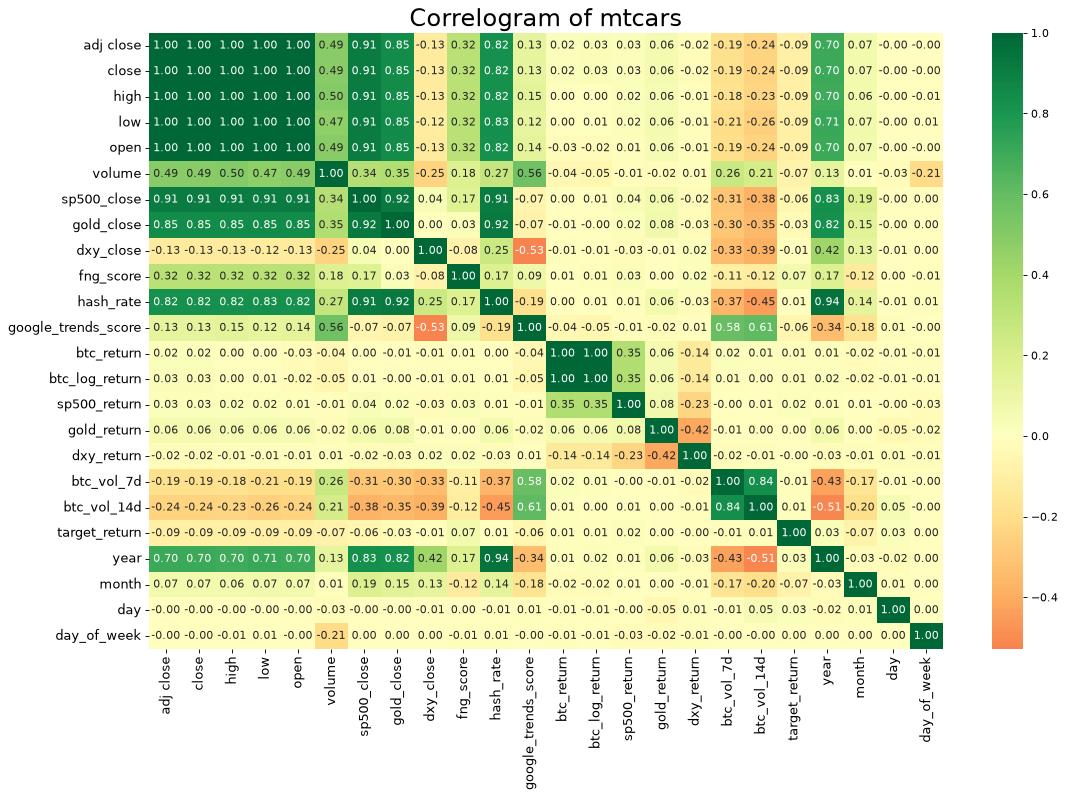

In [5]:
correlogram(df_original)

#### Вывод:
* Заметной корреляции на целевой признак ни один из признаков не имеет. 
* Наблюдаем сильную корреляцию на несокльких группах признаков: 
    * для {open, low, high, close, adj close} оставим adj close, 
    * {btc_return, btc_log_return} -> btc_log_return, 
    * {btc_vol_7d, btc_vol_14d} -> btc_vol_14d
* day_of_week - этот признак в списке малозначимых и заметная корреляция только с volume, но последний влияет заметно на многие признаки, поэтому пока оставим 

In [6]:
df_original = df_original.drop(columns=['open', 'low', 'high', 'close', 'btc_return', 'btc_vol_7d'])

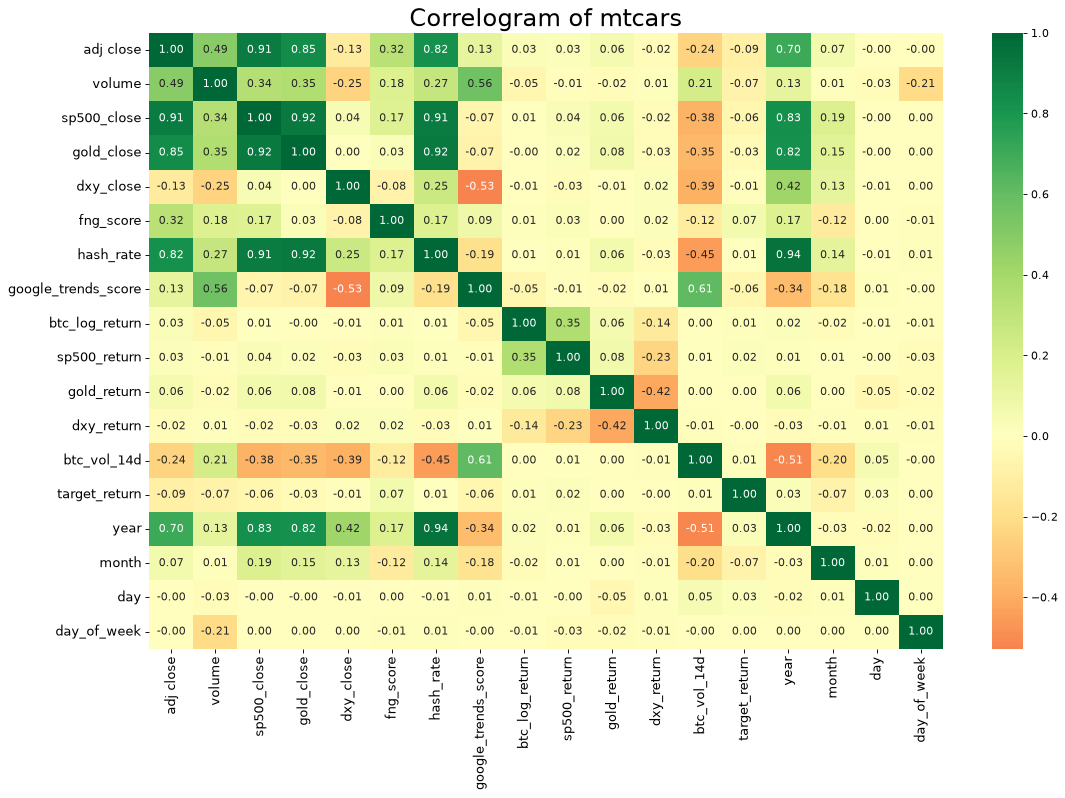

In [7]:
correlogram(df_original)

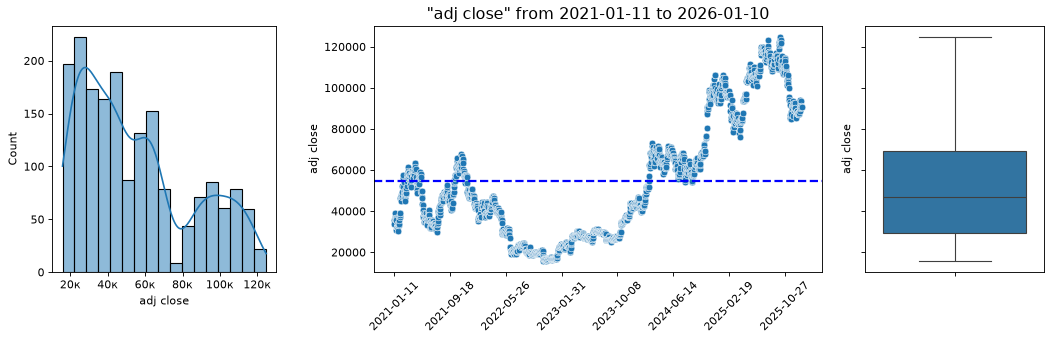

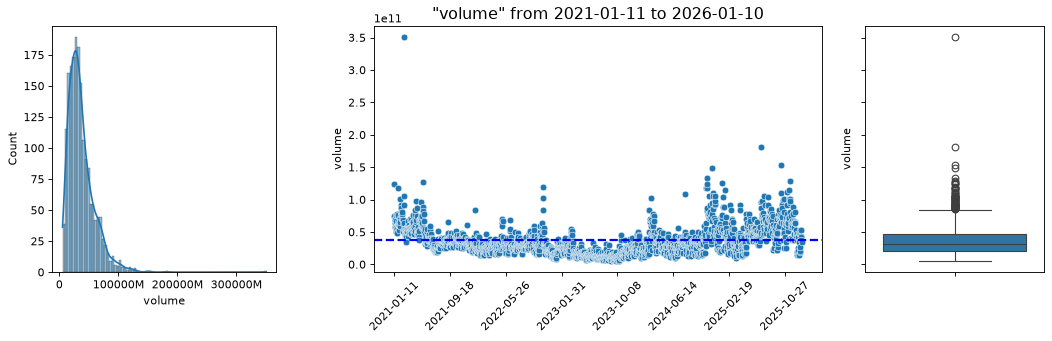

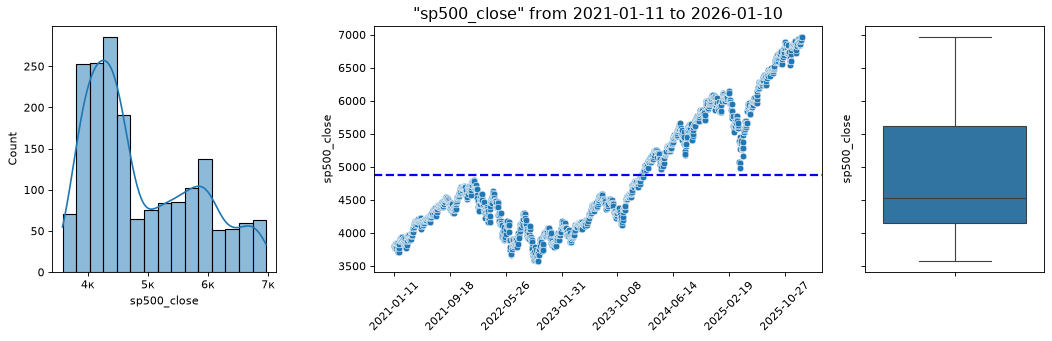

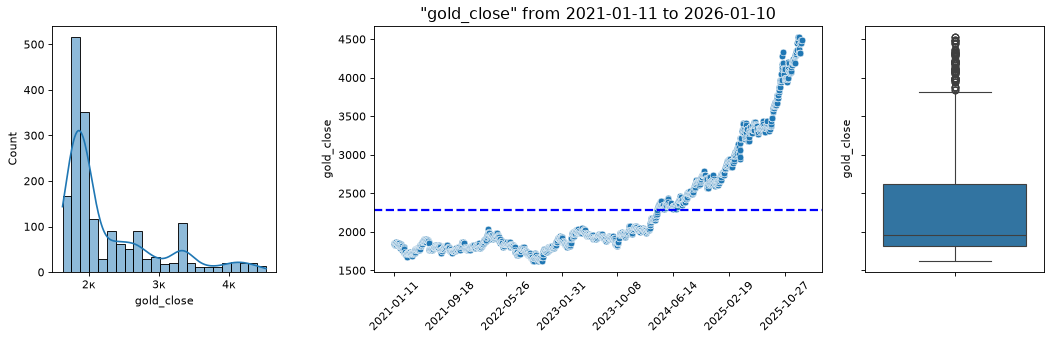

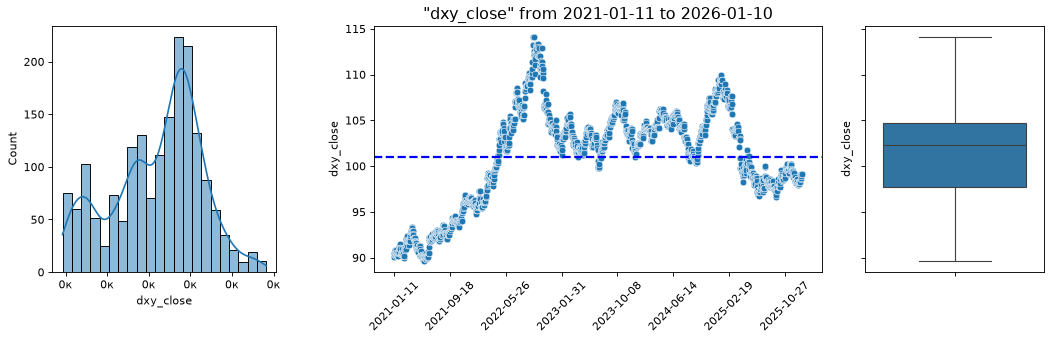

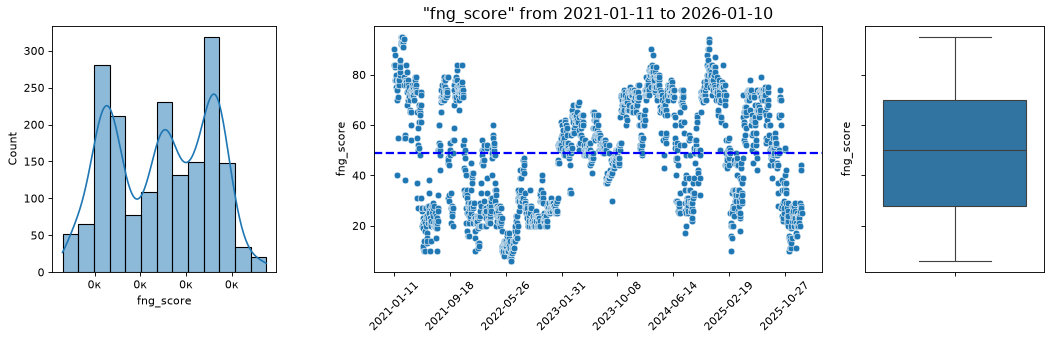

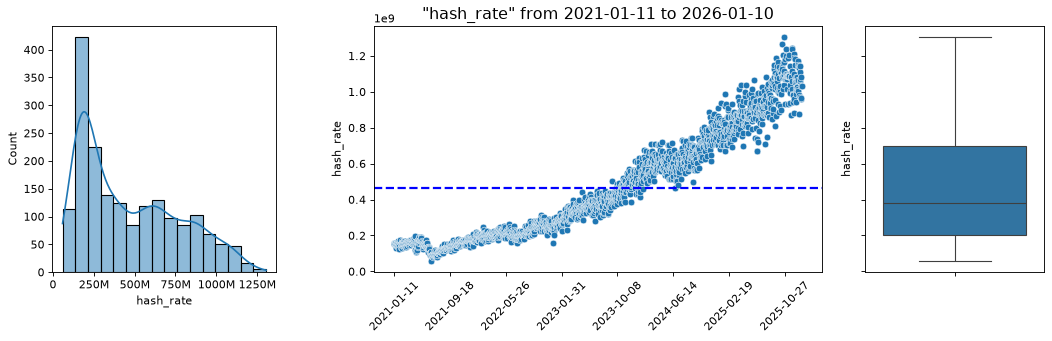

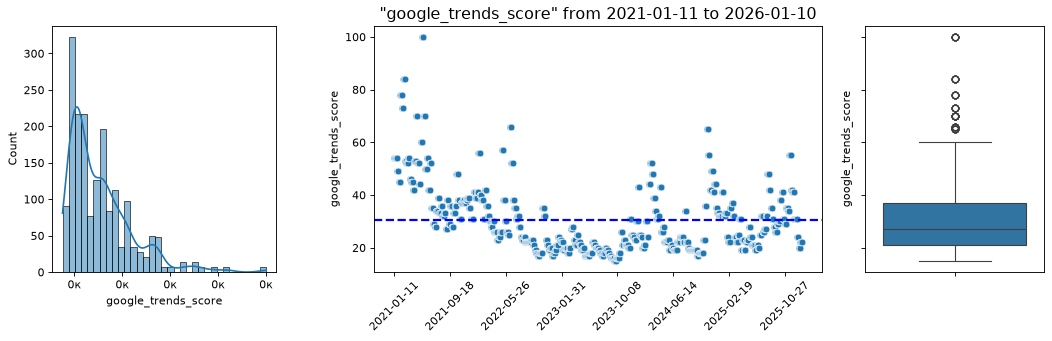

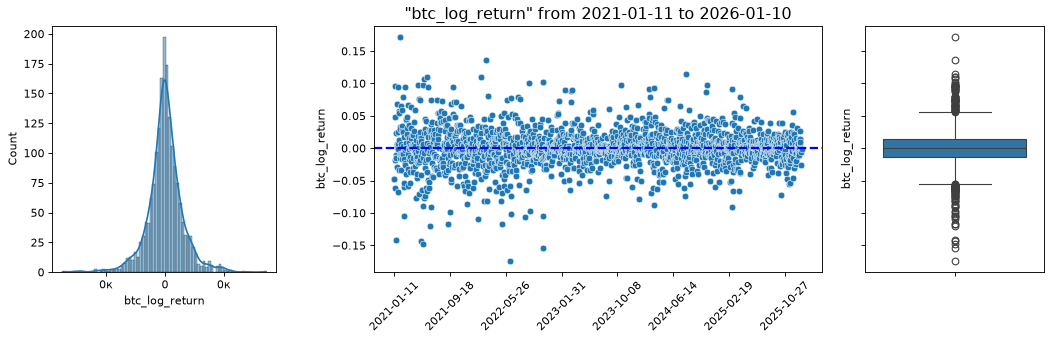

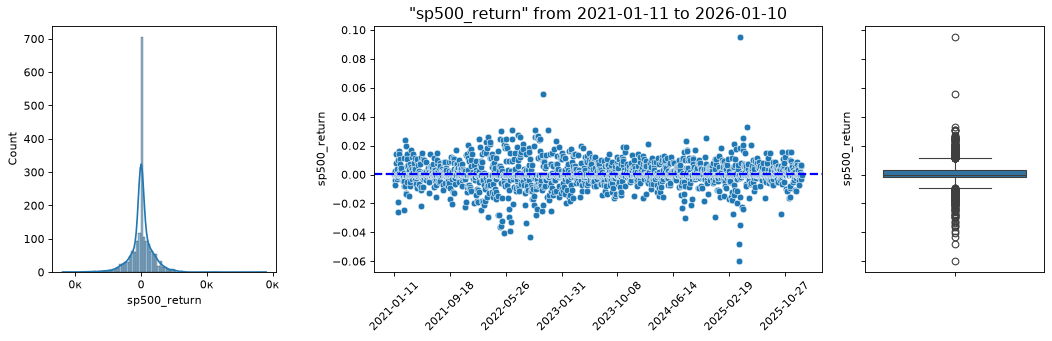

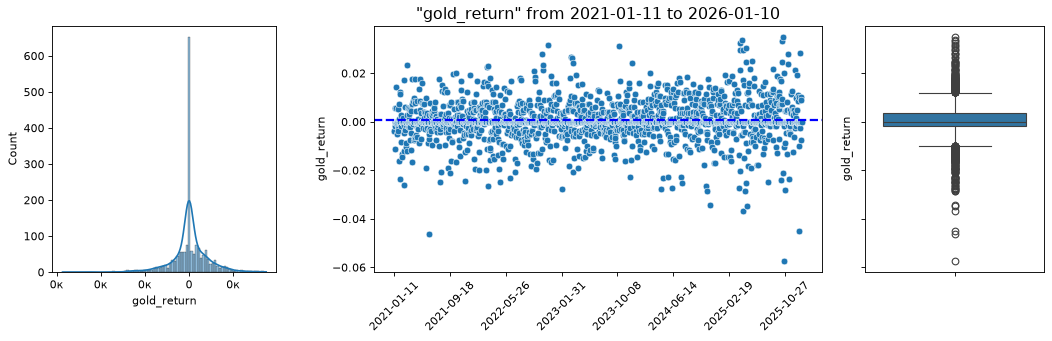

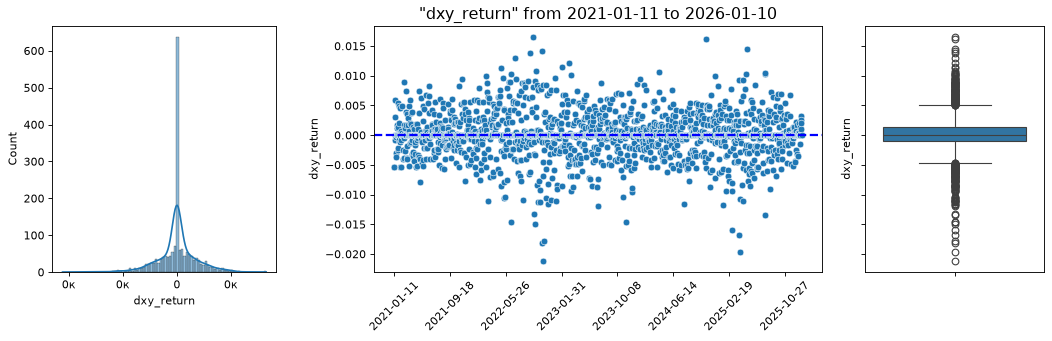

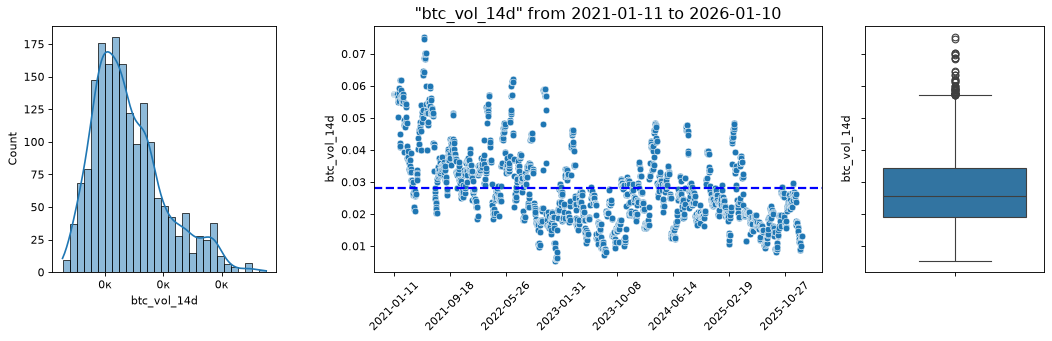

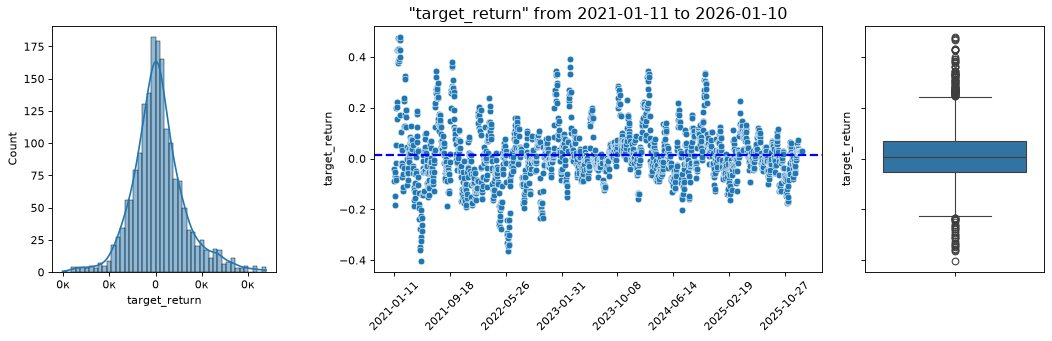

In [9]:
for col in df_original.drop(columns=['year', 'month', 'day', 'day_of_week']).columns:
    feature_plot(df_original, col)

#### Вывод:
1) Как видно, многие из параметров имеют выбросы. Отсеивать их (и признаки, и выбросы) пока не будем. Но будем надяться получить лучшие результаты на алгоритмах, устойчивых к выбросам

#### Сохраним в reduced.csv данные, для которых будем изучать регрессию 

In [10]:
df_original.to_csv("./data/reduced.csv", index=False)
base_report(df_original, "target_return")

rows × cols,n/a,duplicates,0-columns,types
1826×18,0,0,0,"float64(13), int32(4), int64(1)"
